In [1]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount, compute_max_mean_returns_epcount_w_idxs
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import MazeEditor, Observation, ObservedMazeEditor, ObservedMazeEditorWithGoal
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

In [2]:
env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
adv_env = ObservedMazeEditorWithGoal(env, random_z_dimensions=10, zero_out_random_z=False)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

rng = jax.random.PRNGKey(14532)

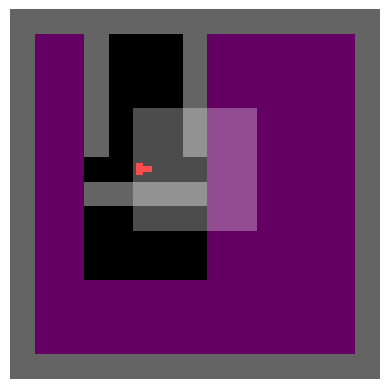

In [4]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

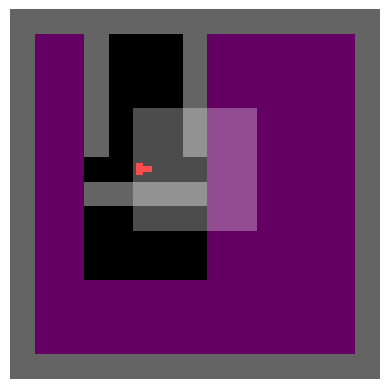

In [71]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

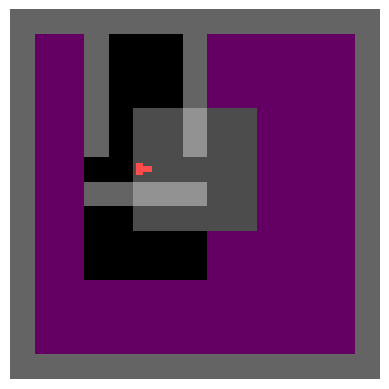

In [64]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 2:9].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

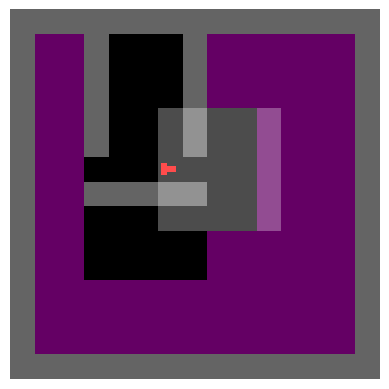

In [72]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 2:9].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([5, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

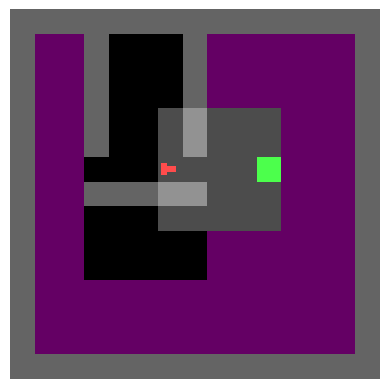

In [63]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 2:10].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([9, 5], dtype=jnp.uint32),
        agent_pos=jnp.array([5, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(True, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

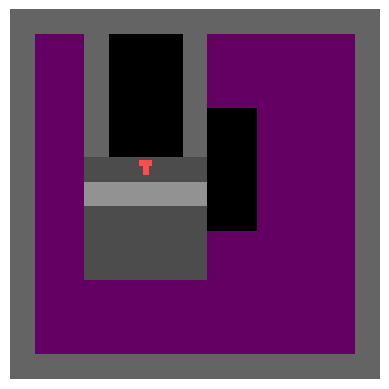

In [69]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 2:9].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(1, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

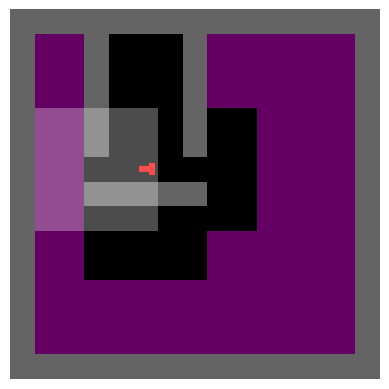

In [73]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 2:9].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(2, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');

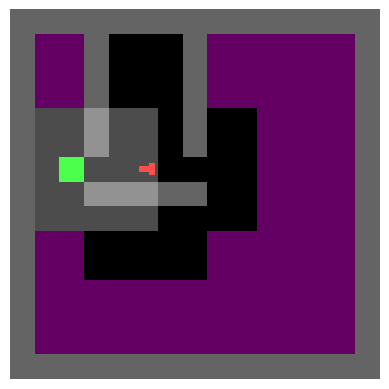

In [62]:
def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    observation_map = observation_map.at[0:10, 2:7].set(True)
    observation_map = observation_map.at[3:8, 0:9].set(True)

    wall_map = jnp.zeros((h, w), dtype=jnp.bool_)
    wall_map = wall_map.at[0:5, 2].set(True)
    wall_map = wall_map.at[0:5, 6].set(True)
    wall_map = wall_map.at[6, 2:7].set(True)
    return ObservedLevel(
        wall_map=wall_map,
        observation_map=observation_map,
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([1, 5], dtype=jnp.uint32),
        agent_pos=jnp.array([4, 5], dtype=jnp.uint32),
        agent_dir=jnp.array(2, dtype=jnp.uint8),
        goal_placed=jnp.array(True, dtype=jnp.bool_),
    )

empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(1, axis=0), sample_empty_level())
_, adv_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng, 1), empty_levels, adv_env_params)

adv_level = jax.tree.map(lambda x: x[0], adv_env_state.level)
adv_image = adv_env_renderer.render_state(adv_level, adv_env_params)
plt.imshow(adv_image)
plt.axis('off');